In [78]:
import numpy as np
import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt

In [79]:
from substrates.gol import GameOfLife
from rollout import rollout_simulation
from functools import partial

In [80]:
substrate = GameOfLife(grid_size=64)
rollout_fn = partial(rollout_simulation, s0=None, substrate=substrate, fm=None, rollout_steps=256, time_sampling='video', img_size=224, return_state=True)
params = substrate.params_cgol
rng = jax.random.PRNGKey(0)
state = rollout_fn(rng, params)['state']

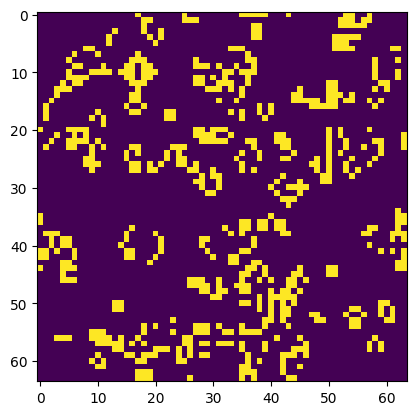

In [81]:
plt.imshow(state[32])

In [82]:
from foundation_models import create_foundation_model

fm = create_foundation_model('clip')

img = jax.random.normal(jax.random.PRNGKey(0), (224, 224, 3))

z_img = fm.embed_img(img)

print(z_img.shape)

(512,)


In [53]:
import optax
import util
from main import Args, ModelArgs
from model import ConvNet
from jax.random import split

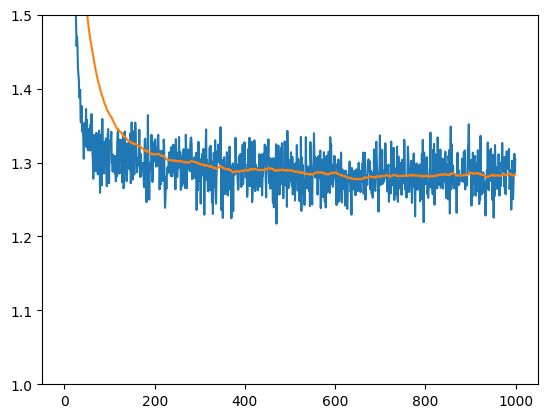

In [72]:
save_dir = "./temp_16"
loss_history = util.load_pkl(save_dir, "loss_history")
args = util.load_pkl(save_dir, "args")
params = util.load_pkl(save_dir, "params")

loss_history = np.array(loss_history)
ppl_history = np.exp(loss_history)
plt.plot(ppl_history)
import pandas as pd
plt.plot(pd.DataFrame(ppl_history).ewm(span=100).mean())
plt.ylim(1, 1.5)
plt.show()

In [73]:
if isinstance(args.dt, int):
    args.dt = [args.dt]
print(args)
dts = jnp.array(args.dt)
dt_max = dts.max().item()

net = ConvNet(layers=args.model.layers, channels=args.model.channels, out_channels=args.model.out_channels)
substrate = GameOfLife(grid_size=args.grid_size)
rollout_fn = partial(rollout_simulation, s0=None, substrate=substrate, fm=None, rollout_steps=args.t_end+dt_max,
                        time_sampling='video', img_size=None, return_state=True)
def generate_batch(rng):
    rng, _rng = split(rng)
    state = rollout_fn(_rng, args.gol_params)['state']

    rng, _rng = split(rng)
    t0 = jax.random.randint(_rng, shape=(), minval=args.t_start, maxval=args.t_end)

    rng, _rng = split(rng)
    dt_id = jax.random.randint(_rng, shape=(), minval=0, maxval=len(dts))
    dt = dts[dt_id]
    t1 = t0 + dt
    x0, x1 = state[t0], state[t1]
    return dict(x0=x0, x1=x1, dt_id=dt_id, dt=dt, state=state, t0=t0, t1=t1)

def loss_fn(params, batch):
    x0, x1, dt_id = batch['x0'], batch['x1'], batch['dt_id']
    logits = jax.vmap(net.apply, in_axes=(None, 0, 0))(params, x0, dt_id) # (B, H, W, 2)
    labels = jax.nn.one_hot(x1, 2) # (B, H, W, 2)

    loss_ce = jax.vmap(jax.vmap(jax.vmap(optax.softmax_cross_entropy)))(logits, labels)
    loss = loss_ce.mean()
    metrics = dict(loss=loss, loss_ce=loss_ce)
    return loss, metrics

Args(seed=0, model=ModelArgs(layers=4, channels=16, out_channels=2), batch_size=32, n_iters=1000, log_every=100, learning_rate=0.0003, weight_decay=1e-05, gol_params=6152, save_dir='./temp_16', grid_size=64, t_start=32, t_end=64, dt=[16], clip_grad_norm=1.0)


In [74]:
generate_batch_vmap = jax.jit(jax.vmap(generate_batch))
rng = jax.random.PRNGKey(1)
batch = generate_batch_vmap(split(rng, args.batch_size))

In [75]:
loss, metrics = loss_fn(params, batch)
print(loss)
print(np.exp(loss))

0.21012953
1.2338378


In [76]:
x0, x1, dt_id = batch['x0'], batch['x1'], batch['dt_id']
logits = jax.vmap(net.apply, in_axes=(None, 0, 0))(params, x0, dt_id)
x1_pred = jnp.argmax(logits, axis=-1)

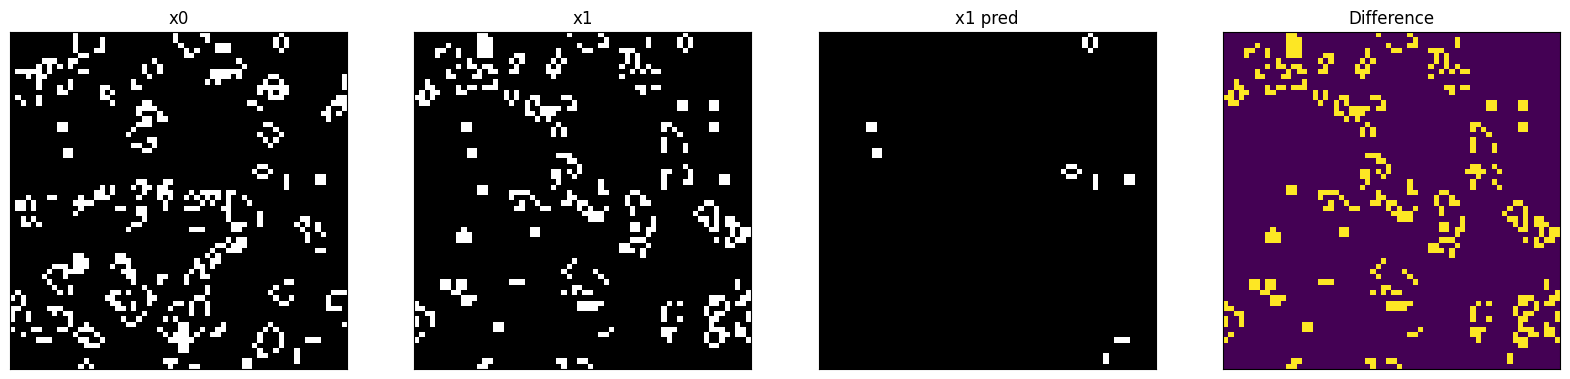

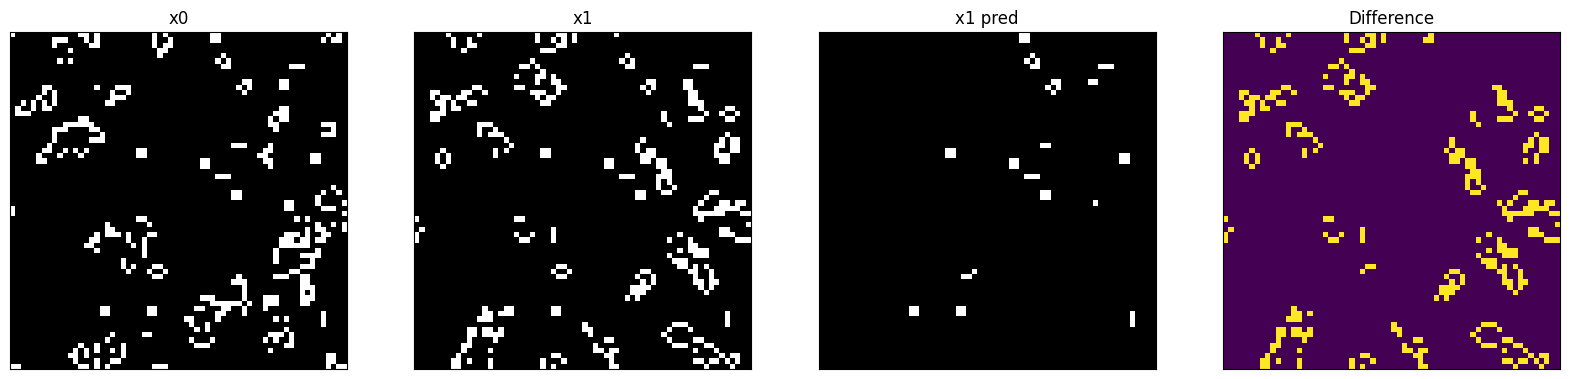

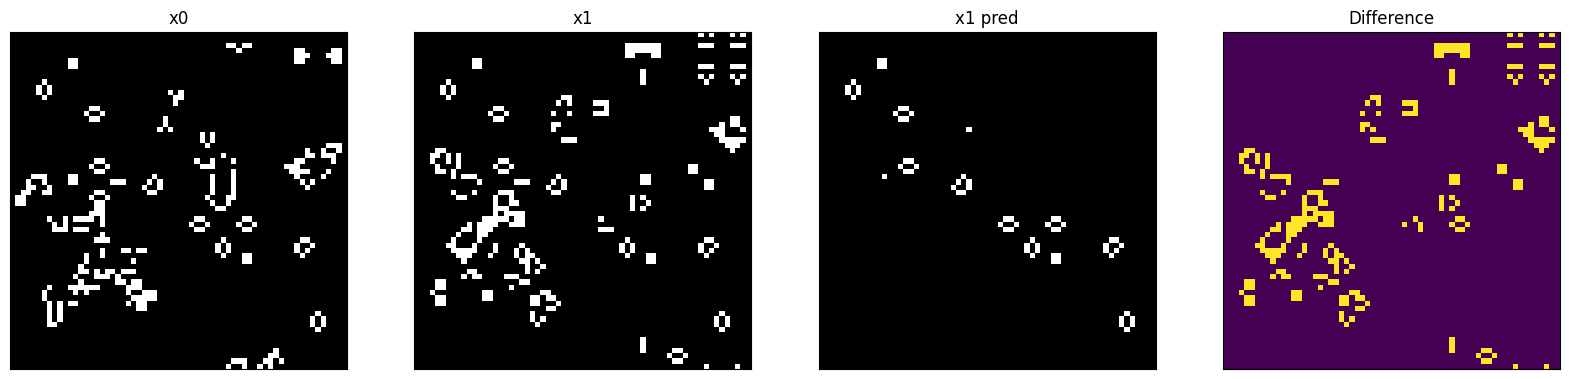

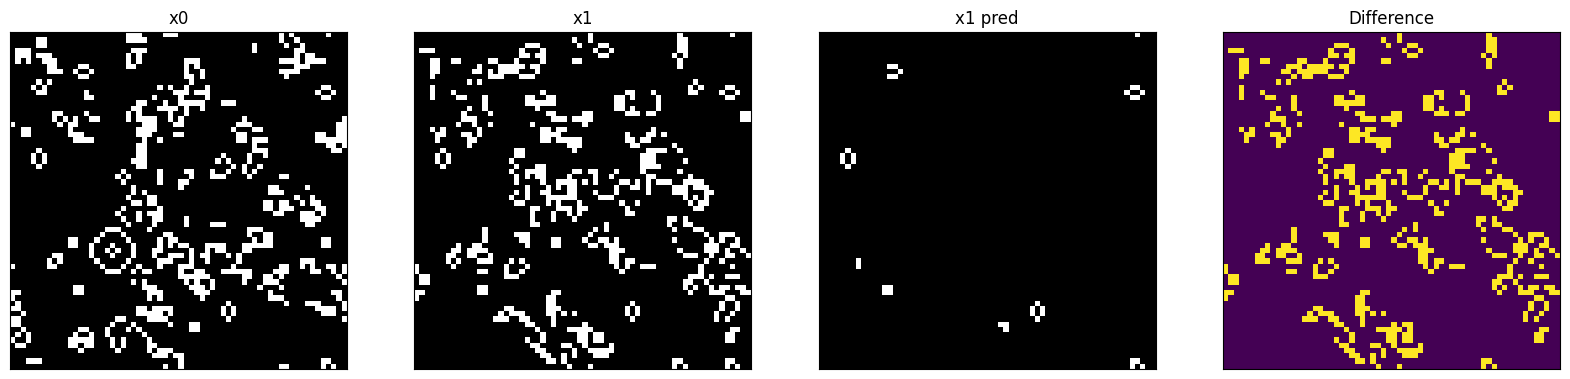

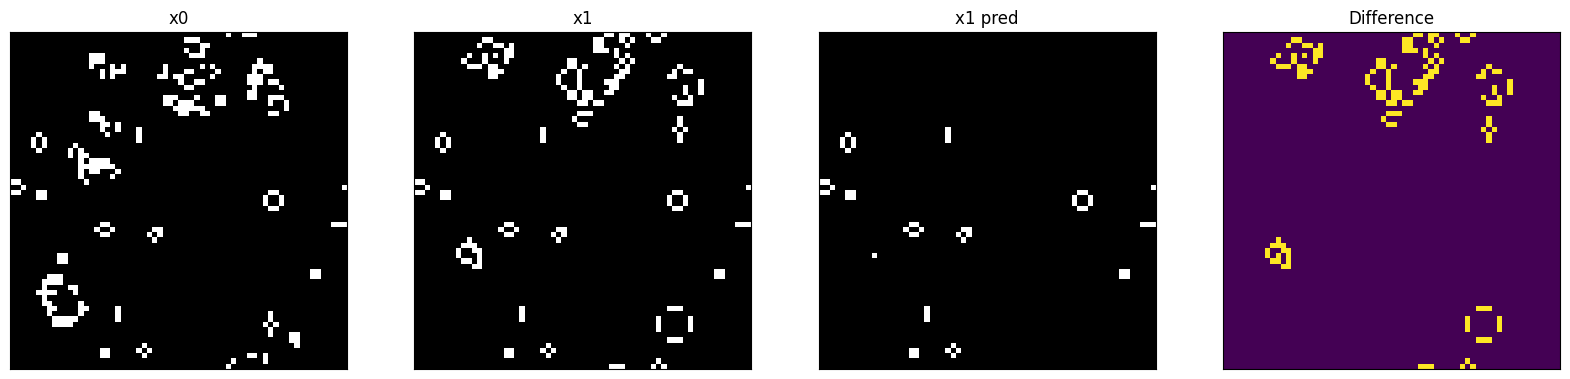

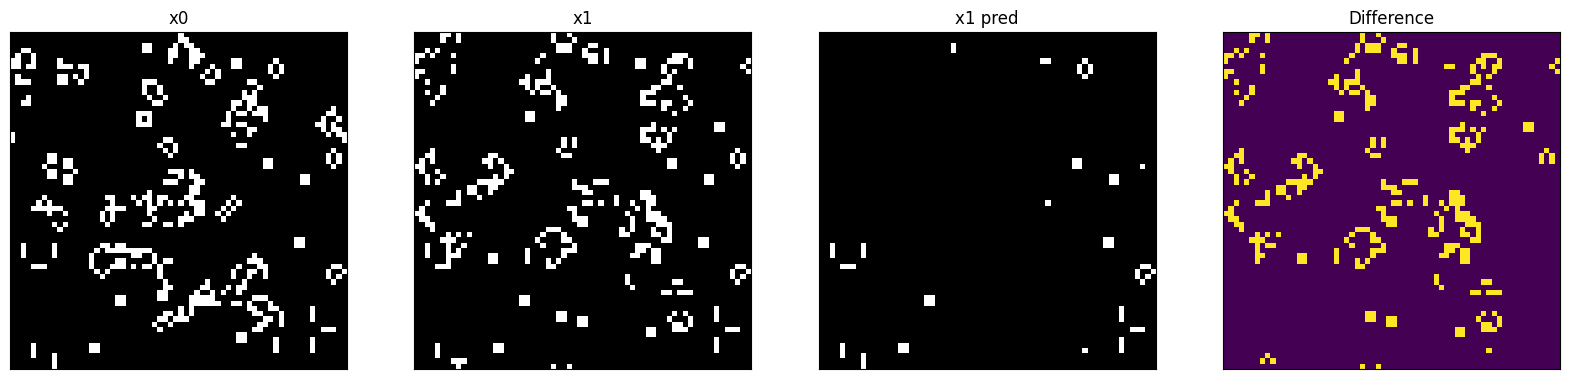

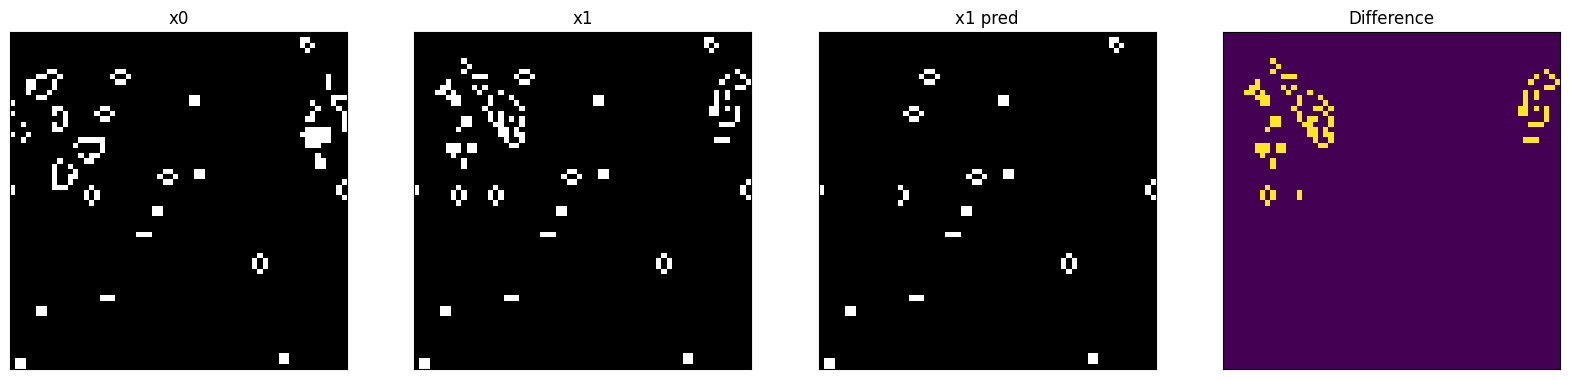

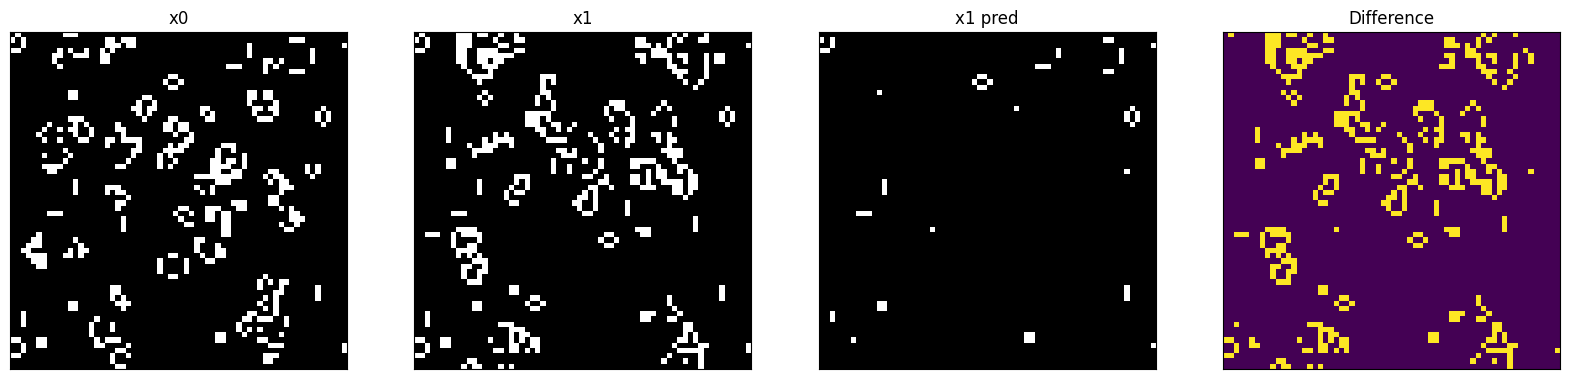

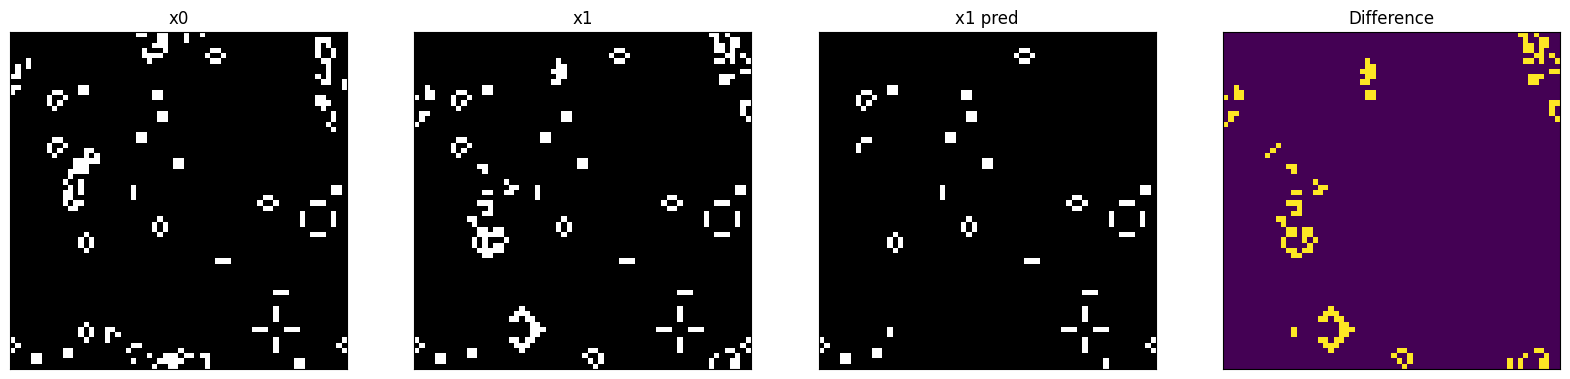

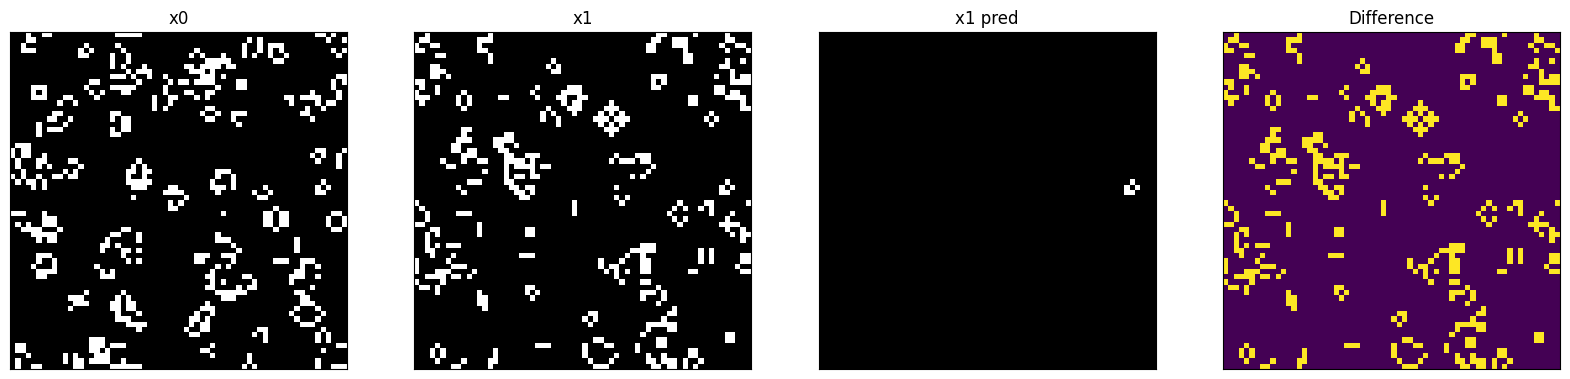

In [77]:
for i in range(10):
    plt.figure(figsize=(20, 5))
    plt.subplot(141); plt.imshow(x0[i], cmap='gray'); plt.title("x0"); plt.xticks([]); plt.yticks([])
    plt.subplot(142); plt.imshow(x1[i], cmap='gray'); plt.title("x1"); plt.xticks([]); plt.yticks([])
    plt.subplot(143); plt.imshow(x1_pred[i], cmap='gray'); plt.title("x1 pred"); plt.xticks([]); plt.yticks([])
    plt.subplot(144); plt.imshow(x1[i]!=x1_pred[i]); plt.title("Difference"); plt.xticks([]); plt.yticks([])
    plt.show()

In [ ]:
python main.py --save_dir ./temp_1  --dt=1  
python main.py --save_dir ./temp_2  --dt=2  
python main.py --save_dir ./temp_4  --dt=4  
python main.py --save_dir ./temp_8  --dt=8  
python main.py --save_dir ./temp_16 --dt=16 

In [38]:
dts = [1, 2, 4, 8, 16]
loss = []
for dt in dts:
    save_dir = f'./temp_{dt}'
    loss_history = util.load_pkl(save_dir, "loss_history")
    loss.append(np.mean(loss_history[-100:]))

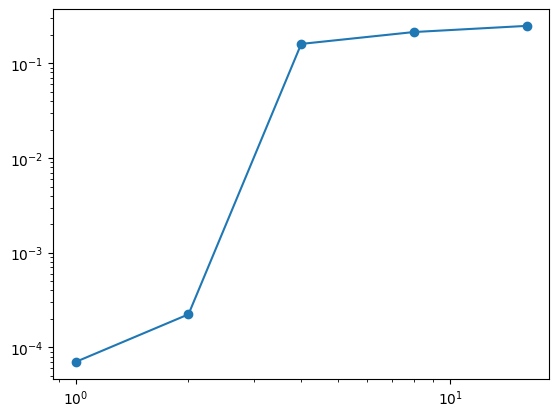

In [39]:
plt.plot(dts, loss)
plt.scatter(dts, loss)
plt.yscale('log')
plt.xscale('log')